<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modul 6 - Spasial Filter**

## Praktikum Filter

0. Membuat fungsi Konvolusi

In [50]:
from google.colab import drive

drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Tambahkan padding jika diperlukan
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Hitung ukuran output
    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1

    # Siapkan array hasil konvolusi
    output = np.zeros((output_height, output_width))

    # Proses konvolusi
    for y in range(0, output_height):
        for x in range(0, output_width):
            region = image[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
            output[y, x] = np.sum(region * kernel)

    return output

1. Muat citra yang akan diproses dan ubah menjadi citra keabuan

In [52]:
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

2. Tentukan kernel yang akan digunakan

In [53]:
kernel_sharpen = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
    ])

3.  Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya:

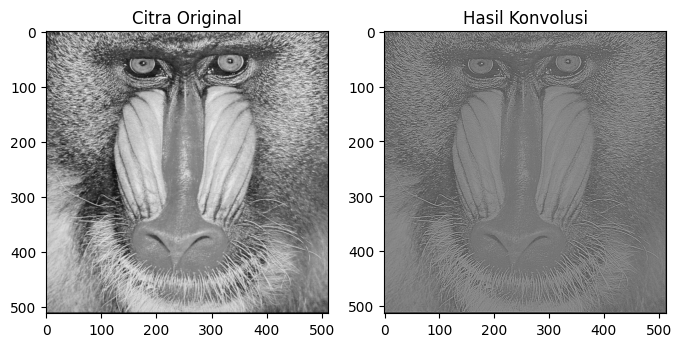

In [54]:
result = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Plot citra asli dan hasil konvolusi
def showImg(img, title):
  fig, axes = plt.subplots(1, 2, figsize=(8,4))

  axes[0].imshow(img_gray, cmap='gray')
  axes[0].set_title("Citra Original")
  axes[0].axis("on")

  axes[1].imshow(img, cmap='gray')
  axes[1].set_title(title)
  axes[1].axis("on")

  plt.show()

showImg(result, "Hasil Konvolusi")

4. Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter

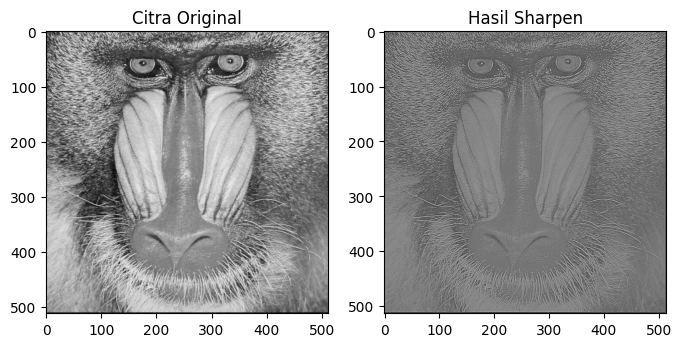

In [55]:
sharpen = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
    ])

result = convolution2d(img_gray, sharpen, 1, 2)
showImg(result, "Hasil Sharpen")

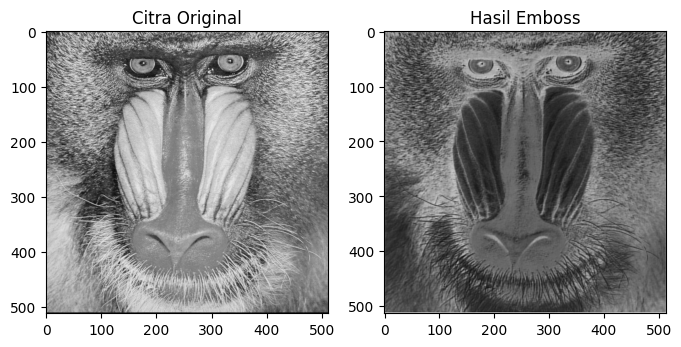

In [56]:
emboss = np.array([
    [-2,-1,0],
    [-1,-1,-1],
    [0,-1,2]
    ])

resultEmboss = convolution2d(img_gray, emboss, 1, 2)
showImg(resultEmboss, "Hasil Emboss")

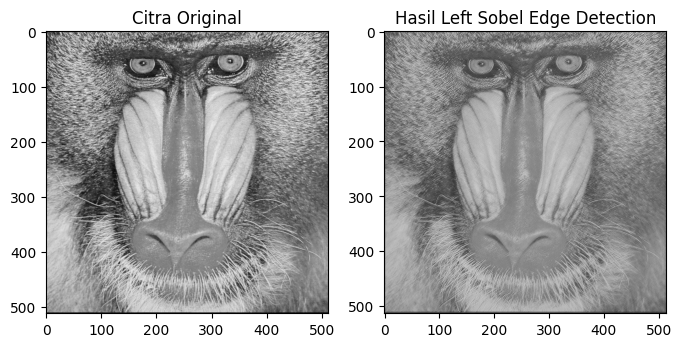

In [57]:
LeftSobelEdgeDetection = np.array([
    [1,0,1],
    [2,0,-2],
    [0,-1,2]
    ])

resultLeftSobelEdgeDetection = convolution2d(img_gray, LeftSobelEdgeDetection, 1, 2)
showImg(resultLeftSobelEdgeDetection, "Hasil Left Sobel Edge Detection")

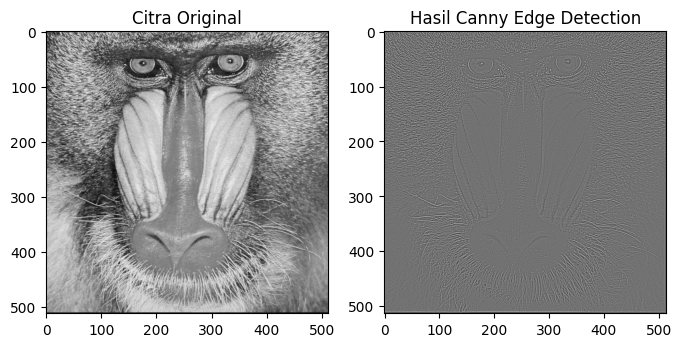

In [58]:
CannyEdgeDetection = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
    ])

resultCannyEdgeDetection = convolution2d(img_gray, CannyEdgeDetection, 1, 2)
showImg(resultCannyEdgeDetection, "Hasil Canny Edge Detection")

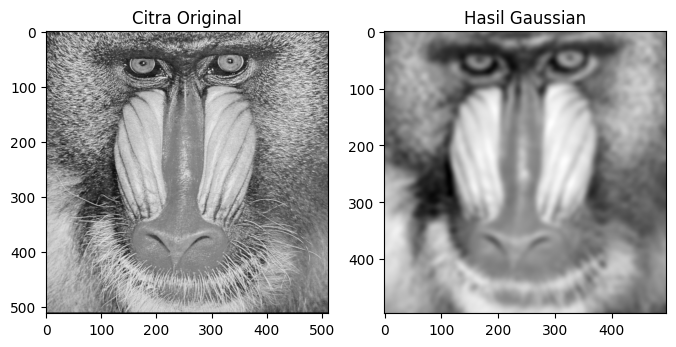

In [59]:
def gaussian_kernel(kernel_size):
    sigma = math.sqrt(kernel_size)
    gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
    gauss_kernel = gaussian_kernel @ gaussian_kernel.T
    return gauss_kernel

kernel_size = 21
g_kernel = gaussian_kernel(kernel_size)
resultGaussian = convolution2d(img_gray, g_kernel, stride=1, padding=2)
showImg(resultGaussian, "Hasil Gaussian")